### Uzair Shaikh
### 1032240100
### DM LCA-3

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

In [43]:
import pandas as pd

df = pd.read_excel(r"D:\MIT WPU B.Tech Data\3nd Year Data\DM\Telco_customer_churn.xlsx\Telco_customer_churn.xlsx")
print(df.head())
print(df.info)


   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [44]:
# Simulate call time categories
df['call_time'] = np.random.choice(['Morning', 'Afternoon', 'Night'], size=len(df))

# Simulate error codes
df['error_code'] = np.random.choice(['200', '404', '500', '503'], size=len(df))

# Simulate network load
df['network_load'] = np.random.choice(['Low', 'Medium', 'High'], size=len(df))

# Simulate switch failure (target)
df['failure'] = np.where(
    (df['error_code'].isin(['500', '503'])) & (df['network_load'] == 'High'),
    'Yes', 'No'
)

In [45]:
df_model = df[['call_time', 'error_code', 'network_load', 'failure']]
df_model.head()

,call_time,error_code,network_load,failure
0,Morning,500,Low,No
1,Night,503,Medium,No
2,Morning,200,Low,No
3,Night,500,Low,No
4,Afternoon,500,Low,No


one hot encoding - converting catogericale data into binary format

In [46]:
df_encoded = pd.get_dummies(df_model)
df_encoded.head()

,call_time_Afternoon,call_time_Morning,call_time_Night,error_code_200,error_code_404,error_code_500,error_code_503,network_load_High,network_load_Low,network_load_Medium,failure_No,failure_Yes
0,False,True,False,False,False,True,False,False,True,False,True,False
1,False,False,True,False,False,False,True,False,False,True,True,False
2,False,True,False,True,False,False,False,False,True,False,True,False
3,False,False,True,False,False,True,False,False,True,False,True,False
4,True,False,False,False,False,True,False,False,True,False,True,False


In [47]:
frequent_itemsets = apriori(df_encoded, 
                           min_support=0.1, 
                           use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.332955,(call_time_Afternoon)
1,0.339628,(call_time_Morning)
2,0.327417,(call_time_Night)
3,0.252733,(error_code_200)
4,0.255431,(error_code_404)


In [48]:
rules = association_rules(frequent_itemsets, 
                         metric="confidence", 
                         min_threshold=0.6)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(call_time_Afternoon),(failure_No),0.332955,0.838279,0.278149,0.835394,0.996559,1.0,-0.000960,0.982475,-0.005150,0.311447,-0.017837,0.583602
1,(call_time_Morning),(failure_No),0.339628,0.838279,0.284964,0.839047,1.000916,1.0,0.000261,1.004770,0.001385,0.319129,0.004747,0.589493
2,(call_time_Night),(failure_No),0.327417,0.838279,0.275167,0.840416,1.002549,1.0,0.000700,1.013392,0.003781,0.308992,0.013215,0.584334
3,(error_code_200),(failure_No),0.252733,0.838279,0.252733,1.000000,1.192920,1.0,0.040872,inf,0.216416,0.301491,1.000000,0.650745
4,(error_code_404),(failure_No),0.255431,0.838279,0.255431,1.000000,1.192920,1.0,0.041309,inf,0.217201,0.304709,1.000000,0.652354


In [49]:
important_rules = rules[
    (rules['lift'] > 1) &
    (rules['confidence'] > 0.7)
]

important_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
1,(call_time_Morning),(failure_No),0.284964,0.839047,1.000916
2,(call_time_Night),(failure_No),0.275167,0.840416,1.002549
3,(error_code_200),(failure_No),0.252733,1.000000,1.192920
4,(error_code_404),(failure_No),0.255431,1.000000,1.192920
7,(failure_Yes),(network_load_High),0.161721,1.000000,3.090391
8,(network_load_Low),(failure_No),0.340196,1.000000,1.192920
9,(network_load_Medium),(failure_No),0.336220,1.000000,1.192920
10,"(call_time_Afternoon, network_load_Low)",(failure_No),0.111884,1.000000,1.192920
11,"(network_load_Medium, call_time_Afternoon)",(failure_No),0.111316,1.000000,1.192920
12,"(call_time_Morning, network_load_Low)",(failure_No),0.116996,1.000000,1.192920


In [50]:
# Function to check if a row matches rule conditions
def check_rule(row, antecedents):
    for item in antecedents:
        if row[item] != 1:
            return False
    return True

In [51]:
# Create a new column for switching decision
df_encoded['switch_decision'] = 'Normal'

# Iterate through rules
for index, rule in important_rules.iterrows():
    
    antecedents = list(rule['antecedents'])
    consequents = list(rule['consequents'])
    
    # Check if rule predicts failure
    if 'failure_Yes' in consequents:
        
        # Apply rule to all rows
        mask = df_encoded.apply(lambda row: check_rule(row, antecedents), axis=1)
        
        # Mark those rows for rerouting
        df_encoded.loc[mask, 'switch_decision'] = 'Reroute'

In [52]:
df_encoded[['switch_decision']].value_counts()

switch_decision
Normal             7043
Name: count, dtype: int64

In [53]:
df_final = df_model.copy()
df_final['switch_decision'] = df_encoded['switch_decision']

df_final.head(10)

,call_time,error_code,network_load,failure,switch_decision
0,Morning,500,Low,No,Normal
1,Night,503,Medium,No,Normal
2,Morning,200,Low,No,Normal
3,Night,500,Low,No,Normal
4,Afternoon,500,Low,No,Normal
5,Morning,500,Medium,No,Normal
6,Afternoon,404,High,No,Normal
7,Afternoon,503,Low,No,Normal
8,Afternoon,200,Medium,No,Normal
9,Afternoon,404,Medium,No,Normal


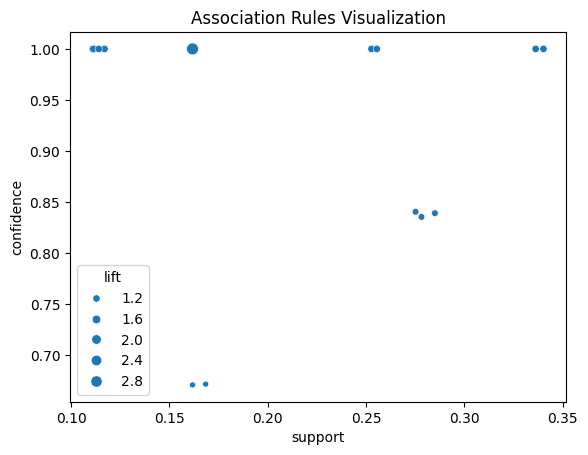

In [54]:
sns.scatterplot(x="support", y="confidence", size="lift", data=rules)
plt.title("Association Rules Visualization")
plt.show()